In [1]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text
import pandas as pd
import numpy as np
import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.1
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [39]:
df = pd.read_csv('spam.csv')
df

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [40]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [41]:
df_spam = df[df['label']=='spam']
df_spam.shape

(747, 2)

In [42]:
df_ham = df[df['label']=='ham']
df_ham.shape

(4825, 2)

In [44]:
from sklearn.utils import resample

df_majority = df[df['label'] == 'ham']
df_minority = df[df['label'] == 'spam']

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df = pd.concat([df_majority, df_minority_upsampled]).sample(frac=1, random_state=42).reset_index(drop=True)

df['label'].value_counts()

label
ham     4825
spam    4825
Name: count, dtype: int64

In [45]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [46]:
df

,label,text
0,0,Mm yes dear look how i am hugging you both. :-P
1,0,But pls dont play in others life.
2,0,i can call in &lt;#&gt; min if thats ok
3,0,HMM yeah if your not too grooved out! And im l...
4,1,"Latest News! Police station toilet stolen, cop..."
...,...,...
9645,1,"SMS SERVICES. for your inclusive text credits,..."
9646,1,"Loan for any purpose å£500 - å£75,000. Homeown..."
9647,1,"If you don't, your prize will go to another cu..."
9648,0,"Ya, told..she was asking wats matter?"


In [47]:
x = df['text']   
y = df['label'] 

In [48]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [49]:
x_train.head()

6993    Not heard from U4 a while. Call 4 rude chat pr...
2629                     Pls send me the correct name da.
4078                         Yeah, where's your class at?
2779                      Yup i've finished c Ì_ there...
1879    The Xmas story is peace.. The Xmas msg is love...
Name: text, dtype: object

In [50]:
bert_preprocess = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3")
bert_encoder = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4")

In [51]:
# Bert layers
text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
preprocessed_text = bert_preprocess(text_input)
outputs = bert_encoder(preprocessed_text)

# Neural network layers
l = tf.keras.layers.Dropout(0.1, name="dropout")(outputs['pooled_output'])
l = tf.keras.layers.Dense(1, activation='sigmoid', name="output")(l)

# Use inputs and outputs to construct a final model
model = tf.keras.Model(inputs=[text_input], outputs = [l])

In [52]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 text (InputLayer)              [(None,)]            0           []                               
                                                                                                  
 keras_layer_2 (KerasLayer)     {'input_mask': (Non  0           ['text[0][0]']                   
                                e, 128),                                                          
                                 'input_type_ids':                                                
                                (None, 128),                                                      
                                 'input_word_ids':                                                
                                (None, 128)}                                                

In [53]:
METRICS = [
      tf.keras.metrics.BinaryAccuracy(name='accuracy'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.Recall(name='recall')
]

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=METRICS)

In [54]:
from tensorflow.keras.callbacks import EarlyStopping

earlystop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=300,
    batch_size=32,
    callbacks=[earlystop]
)

Epoch 1/300
242/242 [==============================] - 34s 125ms/step - loss: 0.4207 - accuracy: 0.8394 - precision: 0.8252 - recall: 0.8611 - val_loss: 0.3070 - val_accuracy: 0.8990 - val_precision: 0.8565 - val_recall: 0.9585
Epoch 2/300
242/242 [==============================] - 29s 120ms/step - loss: 0.2752 - accuracy: 0.9110 - precision: 0.9017 - recall: 0.9225 - val_loss: 0.2471 - val_accuracy: 0.9140 - val_precision: 0.9494 - val_recall: 0.8746
Epoch 3/300
242/242 [==============================] - 29s 121ms/step - loss: 0.2266 - accuracy: 0.9229 - precision: 0.9172 - recall: 0.9298 - val_loss: 0.2043 - val_accuracy: 0.9332 - val_precision: 0.9475 - val_recall: 0.9171
Epoch 4/300
242/242 [==============================] - 29s 119ms/step - loss: 0.1995 - accuracy: 0.9407 - precision: 0.9395 - recall: 0.9420 - val_loss: 0.1852 - val_accuracy: 0.9446 - val_precision: 0.9564 - val_recall: 0.9316
Epoch 5/300
242/242 [==============================] - 29s 120ms/step - loss: 0.1769 - a

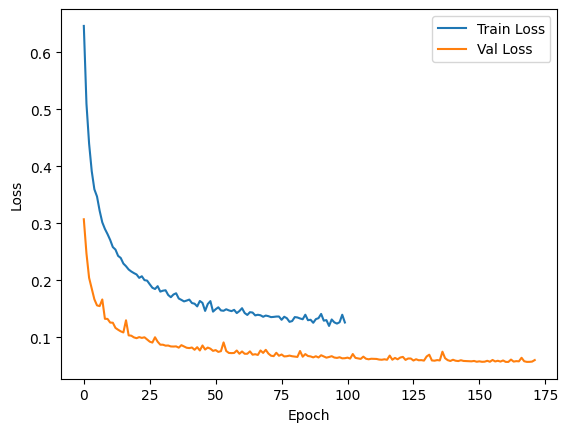

In [55]:
import matplotlib.pyplot as plt
rain_loss = history.history['loss']
val_loss = history.history['val_loss']
plt.plot(train_loss,label="Train Loss")
plt.plot(val_loss,label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [56]:
model.evaluate(x_test, y_test)

61/61 [==============================] - 6s 101ms/step - loss: 0.0569 - accuracy: 0.9829 - precision: 0.9844 - recall: 0.9813


[0.05686416104435921,
 0.9829015731811523,
 0.9844074845314026,
 0.9813471436500549]

In [57]:
y_predicted = model.predict(x_test)
y_predicted = y_predicted.flatten()

61/61 [==============================] - 7s 100ms/step


In [58]:
y_predicted = np.where(y_predicted > 0.5, 1, 0)
y_predicted

array([1, 0, 1, ..., 0, 1, 1])

In [59]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       965
           1       0.98      0.98      0.98       965

    accuracy                           0.98      1930
   macro avg       0.98      0.98      0.98      1930
weighted avg       0.98      0.98      0.98      1930



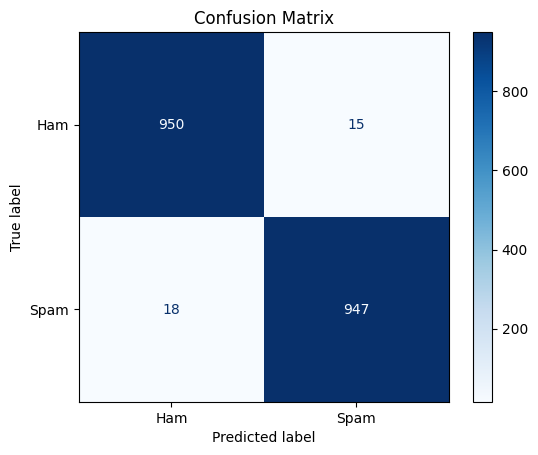

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_predicted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham", "Spam"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [61]:
model.save('text_model.h5')

In [62]:
import tensorflow as tf
import tensorflow_hub as hub

model = tf.keras.models.load_model(
    'text_model.h5',
    custom_objects={'KerasLayer': hub.KerasLayer}
)

In [63]:
#pip install tensorflow_hub

In [81]:
# df_new = pd.DataFrame({
#     "text": [
#         "Your hotel reservation is confirmed for April 12 at 3 PM.",
#         "This is a reminder for your dental appointment next Monday.",
#         "You have a scheduled interview with HR tomorrow at 9 AM.",
#         "Your flight itinerary has been confirmed.",
#         "The meeting room is booked for 10 AM on Friday."
#     ],
#     "label": [0, 0, 0, 0, 0]  
# })

# df_aug = pd.concat([df, df_new], ignore_index=True).sample(frac=1, random_state=42)

# model = tf.keras.models.load_model("text_model.h5", custom_objects={"KerasLayer": hub.KerasLayer})

# history = model.fit(
#     df_aug['text'],
#     df_aug['label'],
#     validation_split=0.2,
#     epochs=5, 
#     batch_size=32
# )

# model.save("text_model_v2.h5")

In [80]:
# import tensorflow as tf
# import tensorflow_hub as hub

# modelv2 = tf.keras.models.load_model(
#     'text_model_v2.h5',
#     custom_objects={'KerasLayer': hub.KerasLayer}
# )

In [77]:
reviews = [
    '''
    Your flight from Jakarta to Singapore has been confirmed. Departure is scheduled for 8:15 AM
    '''
]
model.predict(reviews)

1/1 [==============================] - 0s 30ms/step


array([[0.77165407]], dtype=float32)

In [79]:
# reviews = [
#     '''
#     Your flight from Jakarta to Singapore has been confirmed. Departure is scheduled for 8:15 AM
#     '''
# ]
# modelv2.predict(reviews)

Close to 1 = Spam
Close to 0 = Ham